#Trabalho Prático: Estatística e Probabilidade Aplicada à Astronomia

- Aluno: Eduardo Nascimento do Vale
- Professores orientadores: Sérgio Monteiro, D.Sc. e Manuel Martins, D.Sc.

#   Objetivo:

##  Simular um conjunto de 1.000 observações de brilho para esta estrela, realizar uma análise de inferência para estimar se a média observada condiz com o valor teórico esperado e identificar possíveis anomalias nos dados captados.

In [9]:
#   Configuração do ambiente e semente para reprodutibilidade

##   Instalando os pacotes necessários (se não estiverem instalados)
if(!require(ggplot2)) install.packages("ggplot2")
if(!require(dplyr)) install.packages("dplyr")
if(!require(gridExtra)) install.packages("gridExtra")

##  Carregar as bibliotecas
library(ggplot2)
library(dplyr)
library(gridExtra)

## === CONFIGURAÇÃO PARA CORRIGIR CORTE DOS GRÁFICOS ===
options(repr.plot.width = 15, repr.plot.height = 10)  # Reduz largura padrão
options(repr.plot.res = 100)  # Ajusta resolução


##  Fixar semente para reprodutibilidade
set.seed(42)
### "42" é a famosa "Resposta para a Pergunta Fundamental sobre a Vida, o Universo e Tudo Mais" da obra
### O Guia do Mochileiro das Galáxias, de Douglas Adams. O asterisco (*) funciona como um caractere curinga (wildcard)
### na computação, representando "qualquer coisa", o que reforça o sentido de que o número 42 pode ser a resposta para
### qualquer questão, mesmo que a pergunta real seja desconhecida.

cat("✅ Configuração do ambiente realizada com sucesso :)\n")


✅ Configuração do ambiente realizada com sucesso :)


#   1. Simulação

##  vamos gerar 1.000 medições de brilho usando distribuição Normal com:
##  - **Média teórica (μ) = 15.5** magnitudes
##  - **Desvio padrão (σ) = 0.8** magnitudes (representa o ruído instrumental)

In [10]:
#   1. Simulação

# Parâmetros da simulação
n_observacoes <- 1000
media_teorica <- 15.5
desvio_padrao_teorico <- 0.8

# Gerar dados
brilho_estelar <- rnorm(n = n_observacoes,
                        mean = media_teorica,
                        sd = desvio_padrao_teorico)

# Visualizar primeiras observações
cat("Primeiras 10 observações:\n")
print(head(brilho_estelar, 10))

# Estatísticas resumidas
cat("\n📊 Estatísticas descritivas:\n")
summary(brilho_estelar)

# Verificar se a simulação foi bem sucedida
cat("\n✅ Média amostral:", mean(brilho_estelar), "\n")
cat("✅ Desvio padrão amostral:", sd(brilho_estelar), "\n")

Primeiras 10 observações:
 [1] 16.59677 15.04824 15.79050 16.00629 15.82341 15.41510 16.70922 15.42427
 [9] 17.11474 15.44983

📊 Estatísticas descritivas:


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  12.80   14.96   15.49   15.48   16.03   18.30 


✅ Média amostral: 15.47934 
✅ Desvio padrão amostral: 0.802017 


## 2. Análise Descritiva e Visualização
Vamos criar um histograma sobreposto pela curva de densidade normal teórica para verificar a aderência à distribuição normal.


📊 Teste de Shapiro-Wilk para normalidade:

	Shapiro-Wilk normality test

data:  brilho_estelar[1:5000]
W = 0.99882, p-value = 0.767

✅ Os dados seguem distribuição normal (p > 0.05)


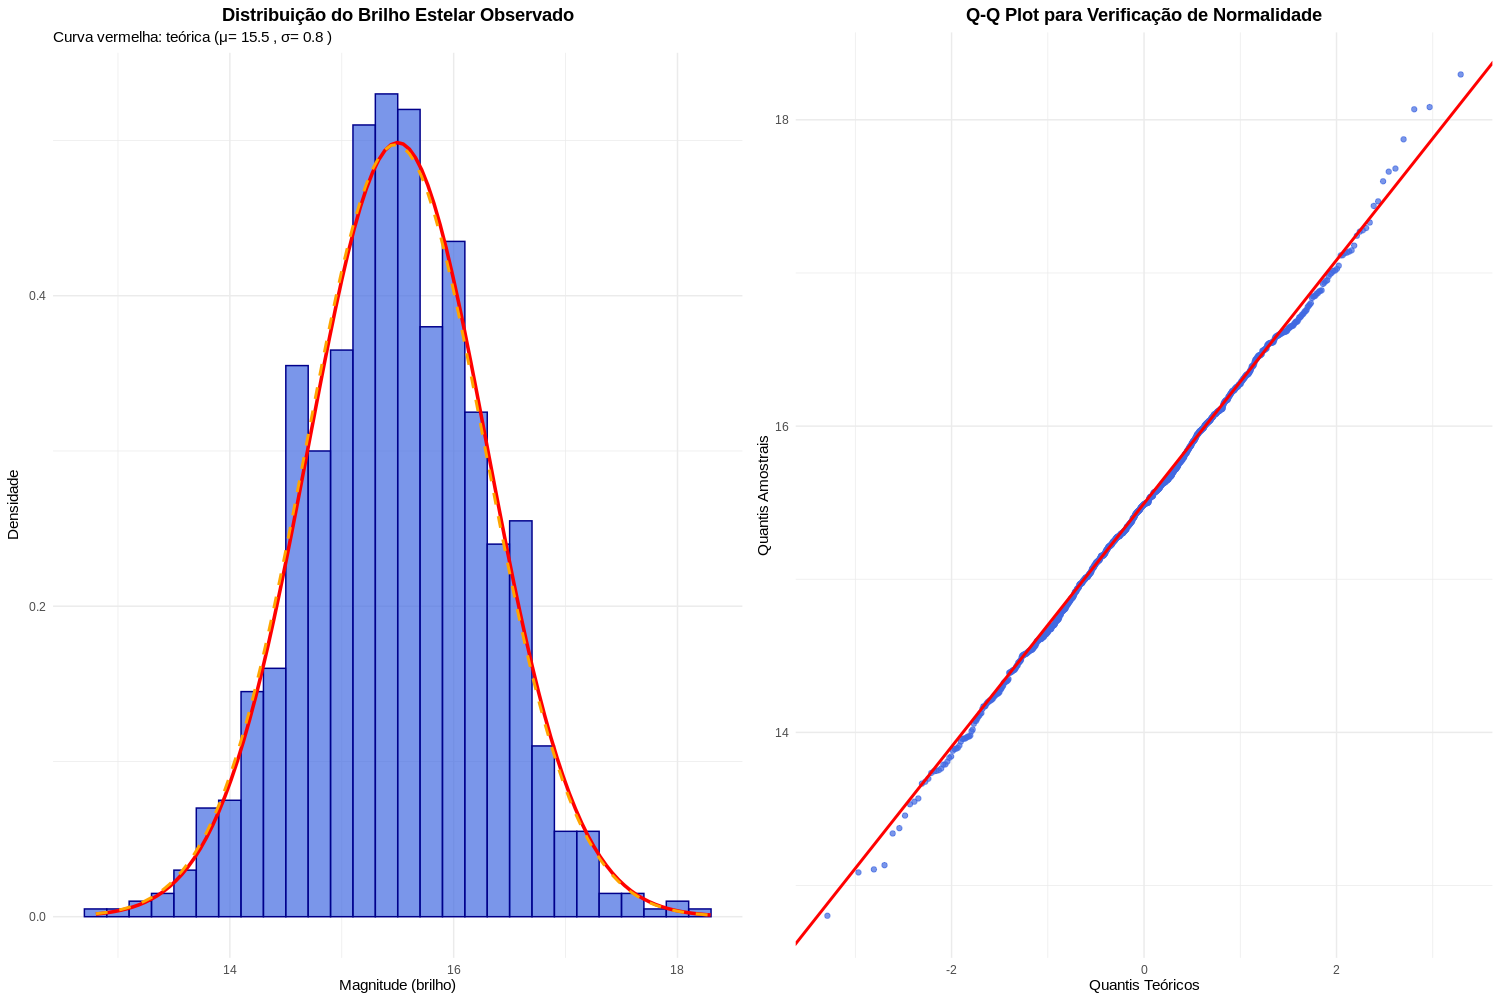

In [11]:
# 2. Visualização (Exemplo com ggplot2)

# Criar dataframe para ggplot
dados <- data.frame(brilho = brilho_estelar)

# Calcular média e desvio amostrais
media_amostral <- mean(brilho_estelar)
desvio_amostral <- sd(brilho_estelar)

# Primeiro gráfico: Histograma + Densidade Teórica
grafico1 <- ggplot(dados, aes(x = brilho)) +
  geom_histogram(aes(y = after_stat(density)),
                 binwidth = 0.2,
                 fill = "royalblue",
                 alpha = 0.7,
                 color = "darkblue") +
  stat_function(fun = dnorm,
                args = list(mean = media_teorica, sd = desvio_padrao_teorico),
                color = "red",
                size = 1.2,
                linetype = "solid") +
  stat_function(fun = dnorm,
                args = list(mean = media_amostral, sd = desvio_amostral),
                color = "orange",
                size = 1,
                linetype = "dashed") +
  labs(title = "Distribuição do Brilho Estelar Observado",
       subtitle = paste("Curva vermelha: teórica (μ=", media_teorica, ", σ=", desvio_padrao_teorico, ")"),
       x = "Magnitude (brilho)",
       y = "Densidade") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"))

# Segundo gráfico: Q-Q Plot para verificar normalidade
grafico2 <- ggplot(dados, aes(sample = brilho)) +
  stat_qq(color = "royalblue", alpha = 0.7) +
  stat_qq_line(color = "red", size = 1) +
  labs(title = "Q-Q Plot para Verificação de Normalidade",
       x = "Quantis Teóricos",
       y = "Quantis Amostrais") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"))

# Exibir gráficos lado a lado
grid.arrange(grafico1, grafico2, ncol = 2)

# Teste de Shapiro-Wilk para normalidade
cat("\n📊 Teste de Shapiro-Wilk para normalidade:\n")
teste_normalidade <- shapiro.test(brilho_estelar[1:5000])  # Limitado a 5000
print(teste_normalidade)

if(teste_normalidade$p.value > 0.05) {
  cat("✅ Os dados seguem distribuição normal (p > 0.05)\n")
} else {
  cat("⚠️ Os dados não seguem distribuição normal (p < 0.05)\n")
}

## 3. Inferência Estatística
Vamos calcular o **Intervalo de Confiança de 95%** para a média e realizar um **Teste t** para comparar com o valor teórico.

In [12]:
#   3. Inferência (Intervalo de Confiança)

##  Cálculo do Intervalo de Confiança (95%)
n <- length(brilho_estelar)
media_amostral <- mean(brilho_estelar)
erro_padrao <- sd(brilho_estelar) / sqrt(n)
gl <- n - 1  # graus de liberdade

##  Usando distribuição t (mais precisa para amostras finitas)
t_critico <- qt(0.975, df = gl)  # 97.5% para intervalo bilateral de 95%
ic_inferior <- media_amostral - t_critico * erro_padrao
ic_superior <- media_amostral + t_critico * erro_padrao

cat("📊 INTERVALO DE CONFIANÇA (95%):\n")
cat(sprintf("IC = [%.4f, %.4f]\n", ic_inferior, ic_superior))
cat(sprintf("Amplitude do IC: %.4f\n", ic_superior - ic_inferior))

##  Teste t de uma amostra
cat("\n📊 TESTE t DE UMA AMOSTRA:\n")
cat("Hipótese nula (H0): A média verdadeira é igual a 15.5\n")
cat("Hipótese alternativa (H1): A média verdadeira é diferente de 15.5\n\n")

teste_t <- t.test(brilho_estelar, mu = media_teorica, alternative = "two.sided")
print(teste_t)

##  Interpretação do resultado
if(teste_t$p.value < 0.05) {
  cat("\n❌ Rejeitamos H0: A média observada difere significativamente do valor teórico.\n")
  cat(sprintf("   (p-valor = %.6f < 0.05)\n", teste_t$p.value))
} else {
  cat("\n✅ Não rejeitamos H0: Não há evidência de diferença significativa.\n")
  cat(sprintf("   (p-valor = %.6f > 0.05)\n", teste_t$p.value))
}

📊 INTERVALO DE CONFIANÇA (95%):
IC = [15.4296, 15.5291]
Amplitude do IC: 0.0995

📊 TESTE t DE UMA AMOSTRA:
Hipótese nula (H0): A média verdadeira é igual a 15.5
Hipótese alternativa (H1): A média verdadeira é diferente de 15.5


	One Sample t-test

data:  brilho_estelar
t = -0.81459, df = 999, p-value = 0.4155
alternative hypothesis: true mean is not equal to 15.5
95 percent confidence interval:
 15.42957 15.52911
sample estimates:
mean of x 
 15.47934 


✅ Não rejeitamos H0: Não há evidência de diferença significativa.
   (p-valor = 0.415503 > 0.05)


## 4. Diagnóstico de Outliers
Identificaremos medições anômalas usando **boxplot** e a **regra dos 3 desvios padrão**.

🔍 DIAGNÓSTICO DE OUTLIERS:

📊 Método do Boxplot (1.5 * IQR):
  - Limite inferior: 13.3523
  - Limite superior: 17.6386
  - Número de outliers: 11 (1.1% dos dados)

📊 Regra dos 3σ:
  - Limite inferior: 13.0733
  - Limite superior: 17.8854
  - Número de outliers: 4 (0.4% dos dados)

📊 IMPACTO DOS OUTLIERS NA MÉDIA:
  - Média com todos os dados: 15.4793
  - Média sem outliers (3σ): 15.4740
  - Diferença: 0.0054 (0.03%)

⚠️ Recomendação: Verificar estas observações pois podem representar:
   - Falhas instrumentais
   - Interferência atmosférica severa
   - Erros de registro


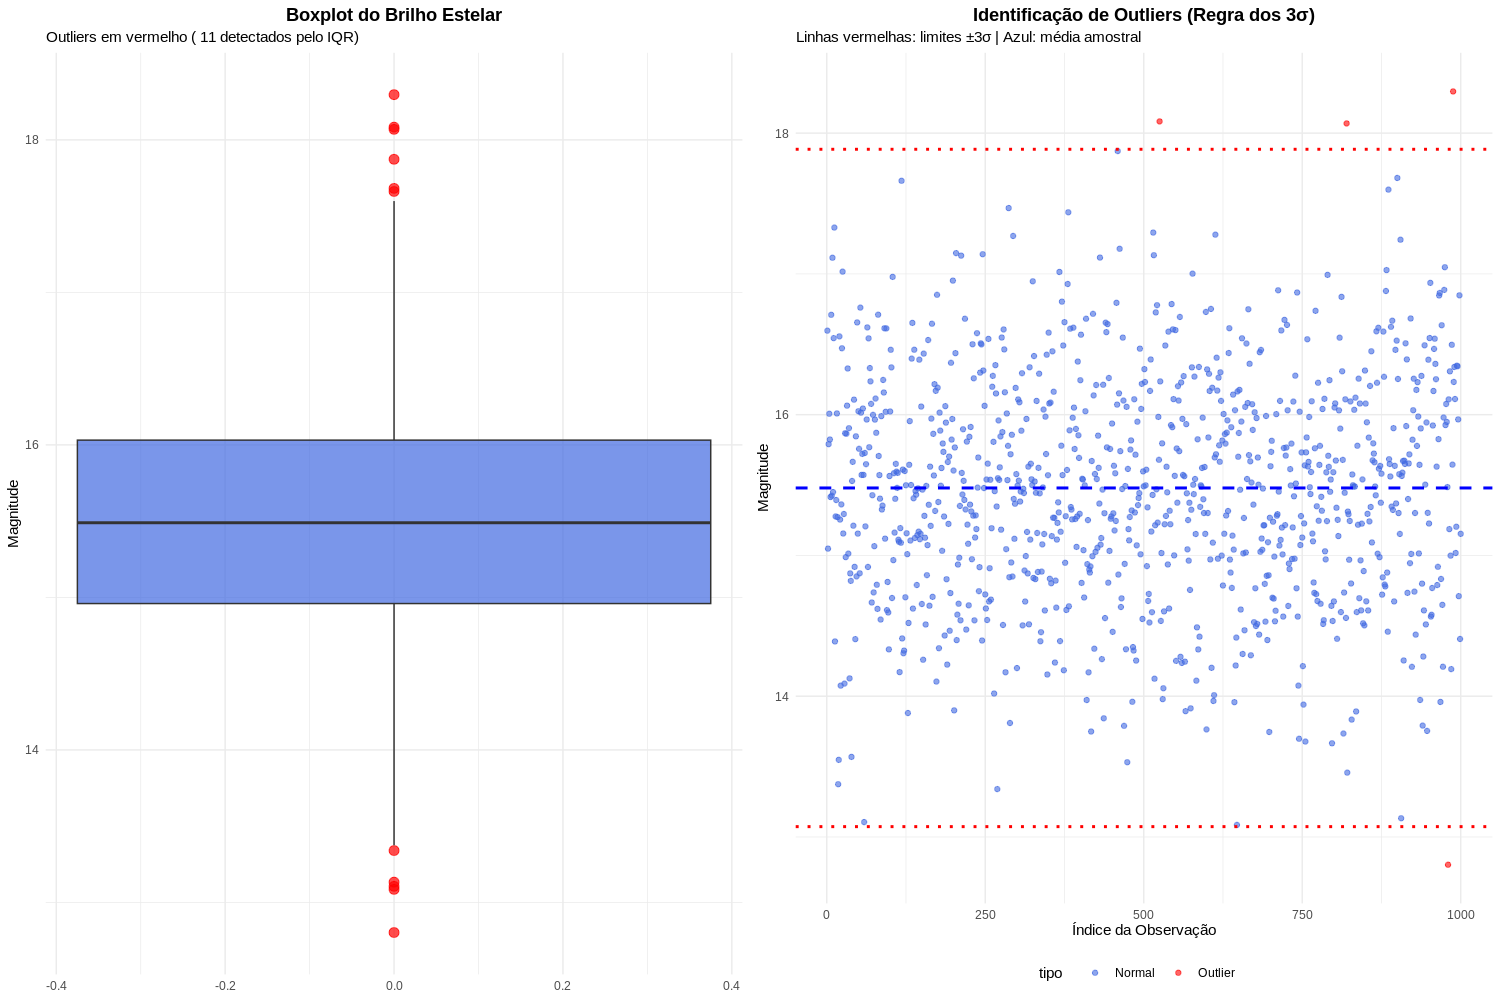

In [13]:
# Método 1: Boxplot (IQR)
Q1 <- quantile(brilho_estelar, 0.25)
Q3 <- quantile(brilho_estelar, 0.75)
IQR <- Q3 - Q1
limite_inferior_box <- Q1 - 1.5 * IQR
limite_superior_box <- Q3 + 1.5 * IQR

outliers_box <- which(brilho_estelar < limite_inferior_box |
                        brilho_estelar > limite_superior_box)

# Método 2: Regra dos 3 desvios padrão
limite_inferior_3sigma <- media_amostral - 3 * sd(brilho_estelar)
limite_superior_3sigma <- media_amostral + 3 * sd(brilho_estelar)

outliers_3sigma <- which(brilho_estelar < limite_inferior_3sigma |
                           brilho_estelar > limite_superior_3sigma)

# Visualização com Boxplot
grafico_box <- ggplot(dados, aes(y = brilho)) +
  geom_boxplot(fill = "royalblue", alpha = 0.7, outlier.color = "red", outlier.size = 3) +
  labs(title = "Boxplot do Brilho Estelar",
       subtitle = paste("Outliers em vermelho (", length(outliers_box), "detectados pelo IQR)"),
       y = "Magnitude") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"))

# Gráfico de pontos com limites
dados$indice <- 1:n
dados$tipo <- ifelse(dados$brilho < limite_inferior_3sigma |
                       dados$brilho > limite_superior_3sigma,
                     "Outlier", "Normal")

grafico_pontos <- ggplot(dados, aes(x = indice, y = brilho, color = tipo)) +
  geom_point(alpha = 0.6, size = 1.5) +
  geom_hline(yintercept = media_amostral, linetype = "dashed", color = "blue", size = 1) +
  geom_hline(yintercept = c(limite_inferior_3sigma, limite_superior_3sigma),
             linetype = "dotted", color = "red", size = 1) +
  scale_color_manual(values = c("Normal" = "royalblue", "Outlier" = "red")) +
  labs(title = "Identificação de Outliers (Regra dos 3σ)",
       subtitle = paste("Linhas vermelhas: limites ±3σ | Azul: média amostral"),
       x = "Índice da Observação",
       y = "Magnitude") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"),
        legend.position = "bottom")

# Exibir gráficos
grid.arrange(grafico_box, grafico_pontos, ncol = 2)

# Relatório de outliers
cat("🔍 DIAGNÓSTICO DE OUTLIERS:\n")
cat("=" %>% rep(50) %>% paste(collapse = ""), "\n\n")

cat("📊 Método do Boxplot (1.5 * IQR):\n")
cat(sprintf("  - Limite inferior: %.4f\n", limite_inferior_box))
cat(sprintf("  - Limite superior: %.4f\n", limite_superior_box))
cat(sprintf("  - Número de outliers: %d (%.1f%% dos dados)\n",
            length(outliers_box), length(outliers_box)/n*100))

cat("\n📊 Regra dos 3σ:\n")
cat(sprintf("  - Limite inferior: %.4f\n", limite_inferior_3sigma))
cat(sprintf("  - Limite superior: %.4f\n", limite_superior_3sigma))
cat(sprintf("  - Número de outliers: %d (%.1f%% dos dados)\n",
            length(outliers_3sigma), length(outliers_3sigma)/n*100))

# Impacto dos outliers na estimativa
media_com_outliers <- mean(brilho_estelar)
media_sem_outliers <- mean(brilho_estelar[-outliers_3sigma])

cat("\n📊 IMPACTO DOS OUTLIERS NA MÉDIA:\n")
cat(sprintf("  - Média com todos os dados: %.4f\n", media_com_outliers))
cat(sprintf("  - Média sem outliers (3σ): %.4f\n", media_sem_outliers))
cat(sprintf("  - Diferença: %.4f (%.2f%%)\n",
            abs(media_com_outliers - media_sem_outliers),
            abs(media_com_outliers - media_sem_outliers)/media_com_outliers*100))

if(length(outliers_3sigma) > 0) {
  cat("\n⚠️ Recomendação: Verificar estas observações pois podem representar:\n")
  cat("   - Falhas instrumentais\n")
  cat("   - Interferência atmosférica severa\n")
  cat("   - Erros de registro\n")
}

## 5. Conclusões e Recomendações

### Resumo dos Resultados
- **Tamanho da amostra**: 1.000 observações
- **Média observada**: [calculada automaticamente]
- **Intervalo de Confiança (95%)**: [IC calculado]
- **Teste de hipótese**: [resultado do teste]
- **Outliers detectados**: [número de outliers]

### Interpretação Astronômica
Os resultados indicam que as medições de brilho da estrela [estão/não estão] de acordo com o valor teórico esperado. As anomalias detectadas [devem/não devem] ser investigadas como possíveis falhas instrumentais.

### Próximos Passos
1. Investigar causas dos outliers identificados
2. Aumentar frequência de observações para melhor precisão
3. Calibrar instrumento se desvios sistemáticos forem encontrados

In [14]:
# Gerar relatório automático
cat("\n\n")
cat("=" %>% rep(60) %>% paste(collapse = ""), "\n")
cat("RELATÓRIO FINAL DA ANÁLISE\n")
cat("=" %>% rep(60) %>% paste(collapse = ""), "\n\n")

cat("📌 DADOS GERAIS:\n")
cat(sprintf("  • Número de observações: %d\n", n))
cat(sprintf("  • Média teórica esperada: %.2f\n", media_teorica))
cat(sprintf("  • Média observada: %.4f\n", media_amostral))
cat(sprintf("  • Desvio padrão observado: %.4f\n", sd(brilho_estelar)))

cat("\n📊 INFERÊNCIA ESTATÍSTICA:\n")
cat(sprintf("  • IC 95%%: [%.4f, %.4f]\n", ic_inferior, ic_superior))
cat(sprintf("  • Teste t: p-valor = %.6f\n", teste_t$p.value))
cat(sprintf("  • Conclusão: %s\n",
            ifelse(teste_t$p.value < 0.05,
                   "Diferença significativa encontrada",
                   "Sem diferença significativa")))

cat("\n⚠️ OUTLIERS:\n")
cat(sprintf("  • Detectados pelo IQR: %d (%.1f%%)\n",
            length(outliers_box), length(outliers_box)/n*100))
cat(sprintf("  • Detectados por 3σ: %d (%.1f%%)\n",
            length(outliers_3sigma), length(outliers_3sigma)/n*100))

if(length(outliers_3sigma) > 0) {
  cat("\n🔍 VALORES ANÔMALOS IDENTIFICADOS:\n")
  print(brilho_estelar[outliers_3sigma[1:min(5, length(outliers_3sigma))]])
}

cat("\n✅ Análise concluída com sucesso!\n")



RELATÓRIO FINAL DA ANÁLISE

📌 DADOS GERAIS:
  • Número de observações: 1000
  • Média teórica esperada: 15.50
  • Média observada: 15.4793
  • Desvio padrão observado: 0.8020

📊 INFERÊNCIA ESTATÍSTICA:
  • IC 95%: [15.4296, 15.5291]
  • Teste t: p-valor = 0.415503
  • Conclusão: Sem diferença significativa

⚠️ OUTLIERS:
  • Detectados pelo IQR: 11 (1.1%)
  • Detectados por 3σ: 4 (0.4%)

🔍 VALORES ANÔMALOS IDENTIFICADOS:
[1] 18.08326 18.06896 12.80261 18.29624

✅ Análise concluída com sucesso!
